In [ ]:
!pip install qiskit qiskit_aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


[True Markovian] Step 1 | S(R) ≈ 1.0000
[True Markovian] Step 2 | S(R) ≈ 2.0000
[True Markovian] Step 3 | S(R) ≈ 3.0000
[True Markovian] Step 4 | S(R) ≈ 4.0000
[True Markovian] Step 5 | S(R) ≈ 5.0000
[True Markovian] Step 6 | S(R) ≈ 6.0000
[True Markovian] Step 7 | S(R) ≈ 7.0000
[True Markovian] Step 8 | S(R) ≈ 8.0000
[True Markovian] Step 9 | S(R) ≈ 9.0000
[True Markovian] Step 10 | S(R) ≈ 10.0000
[Non-Markovian] Step 1 | S(R) = 0.9999
[Non-Markovian] Step 2 | S(R) = 1.9992
[Non-Markovian] Step 3 | S(R) = 2.9967
[Non-Markovian] Step 4 | S(R) = 3.9895
[Non-Markovian] Step 5 | S(R) = 4.9575
[Non-Markovian] Step 6 | S(R) = 5.8190
[Non-Markovian] Step 7 | S(R) = 6.2867
[Non-Markovian] Step 8 | S(R) = 5.8216
[Non-Markovian] Step 9 | S(R) = 4.9536
[Non-Markovian] Step 10 | S(R) = 3.9913


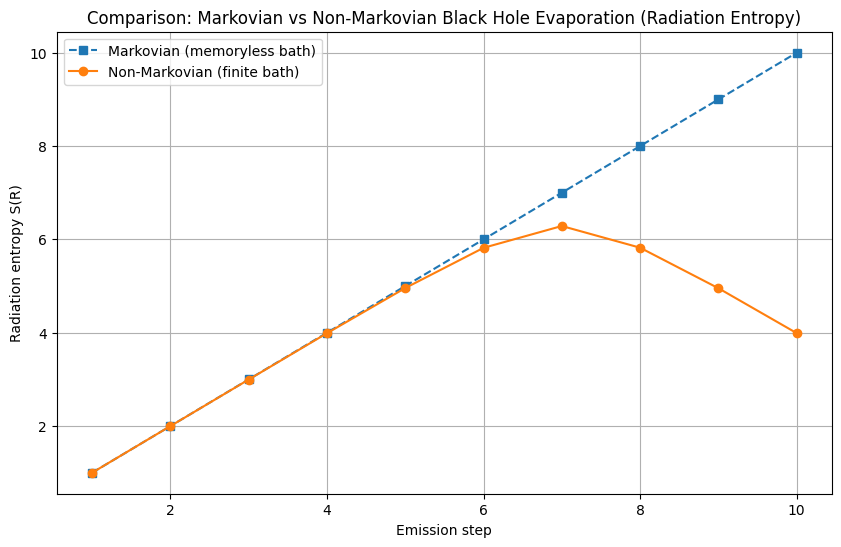

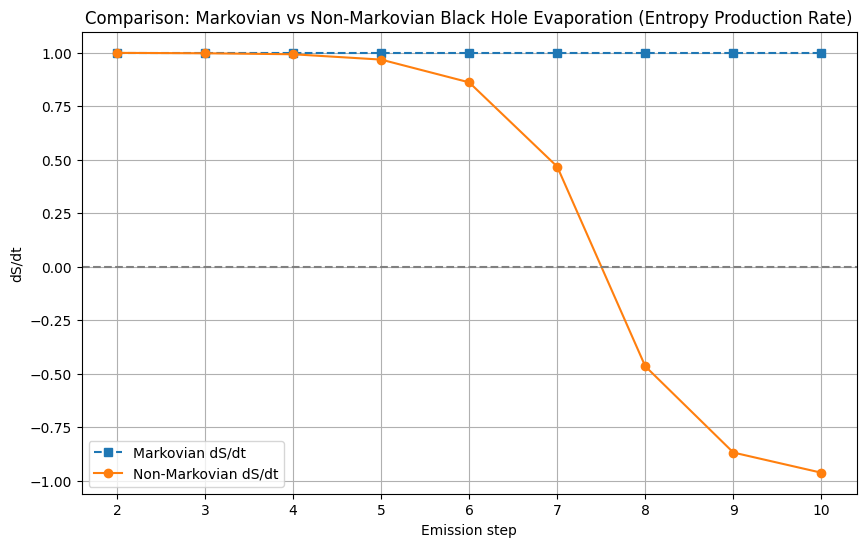

In [ ]:
%run MvNM_base.ipynb

Simulating discrete BH-to-Environment OTOC on 15 qubits...
Step 0 | Re[OTOC] = 1.0000
Step 1 | Re[OTOC] = 0.0029
Step 2 | Re[OTOC] = 0.0020
Step 3 | Re[OTOC] = -0.0107
Step 4 | Re[OTOC] = 0.0127
Step 5 | Re[OTOC] = -0.0049
Step 6 | Re[OTOC] = 0.0273


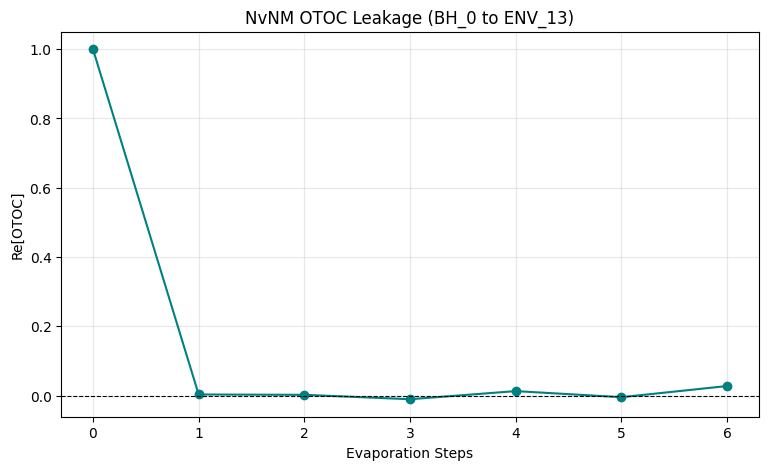

In [ ]:
# 2. Setup OTOC System Size
ancilla_qubit_index = TOTAL_QUBITS # Index 12 (the 13th qubit)
otoc_total_qubits = TOTAL_QUBITS + 1

# 3. FREEZE THE DYNAMICS (The Randomness Fix)
# We must generate the random angles ONCE to ensure U_dag perfectly reverses U
step_qc = QuantumCircuit(TOTAL_QUBITS, name="U_NvNM_step")

bh_qubits = list(range(N_BH))
env_qubits = list(range(N_BH, TOTAL_QUBITS))

# Apply one discrete step of your exact NvNM dynamics
scramble_black_hole(step_qc, bh_qubits)
evolve_environment(step_qc, env_qubits)
bh_environment_interaction(step_qc, bh_qubits, env_qubits)

# Convert to fixed gates
U_step_gate = step_qc.to_gate()
U_step_dag_gate = U_step_gate.inverse()

# 4. Simulation Loop
simulator = AerSimulator()
shots = 2048

# We only need a few steps because 20 layers of scrambling is extremely fast
max_steps = 6
time_steps = list(range(max_steps + 1))
otoc_values = []

print(f"Simulating discrete BH-to-Environment OTOC on {otoc_total_qubits} qubits...")

for step in time_steps:
    qc = QuantumCircuit(otoc_total_qubits, 1)
    qc.h(ancilla_qubit_index)

    sys_qubits = list(range(TOTAL_QUBITS))

    # --- The Leakage OTOC Sequence ---
    # V on Qubit 0 (Deep inside Black Hole)
    qc.cz(ancilla_qubit_index, 0)

    # Forward Time Evolution (apply 'step' times)
    for _ in range(step):
        qc.append(U_step_gate, sys_qubits)

    # W on the last Environment Qubit (Edge of the radiation bath)
    w_index = TOTAL_QUBITS - 1
    qc.x(w_index)

    # Backward Time Evolution
    for _ in range(step):
        qc.append(U_step_dag_gate, sys_qubits)

    # V_dag
    qc.cz(ancilla_qubit_index, 0)

    # Forward Time
    for _ in range(step):
        qc.append(U_step_gate, sys_qubits)

    # W_dag
    qc.x(w_index)

    # Backward Time
    for _ in range(step):
        qc.append(U_step_dag_gate, sys_qubits)
    # ---------------------------------

    # Measure
    qc.h(ancilla_qubit_index)
    qc.measure(ancilla_qubit_index, 0)

    # Run
    qc_flat = qc.decompose()
    qc_transpiled = transpile(qc_flat, simulator)
    result = simulator.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()

    p_0 = counts.get('0', 0) / shots
    otoc_real = 2 * p_0 - 1
    otoc_values.append(otoc_real)
    print(f"Step {step} | Re[OTOC] = {otoc_real:.4f}")

# 5. Plotting
plt.figure(figsize=(9, 5))
plt.plot(time_steps, otoc_values, marker='o', linestyle='-', color='teal')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(f"MvNM OTOC Leakage (BH_0 to ENV_{TOTAL_QUBITS-1})")
plt.xlabel("Evaporation Steps")
plt.ylabel("Re[OTOC]")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your saved CSV files
try:
    df_nvnm = pd.read_csv('otoc_nvnm_data.csv')
    df_markovian = pd.read_csv('otoc_markovian_data.csv')

    # 2. Set up the plot
    plt.figure(figsize=(9, 5))

    # 3. Plot Non-Markovian (NvNM) Data
    plt.plot(df_nvnm['Step'], df_nvnm['Re_OTOC'],
             marker='o', linestyle='-', color='teal', linewidth=2,
             label='Non-Markovian (Memory Retained)')

    # 4. Plot Markovian (M) Data
    plt.plot(df_markovian['Step'], df_markovian['Re_OTOC'],
             marker='s', linestyle='--', color='darkorange', linewidth=2,
             label='Markovian (Memoryless)')

    # 5. Formatting
    plt.axhline(0, color='black', linestyle=':', linewidth=1)
    plt.title("Information Leakage Comparison: NvNM vs. Markovian Black Hole")
    plt.xlabel("Evaporation Steps")
    plt.ylabel("Re[OTOC] (Scrambling Fidelity)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Save a high-res image for your paper/presentation
    plt.savefig('OTOC_Comparison_Plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Comparison plot generated and saved as 'OTOC_Comparison_Plot.png'")

except FileNotFoundError:
    print("Error: Could not find the CSV files. Make sure you ran both simulations and saved the data first!")

Error: Could not find the CSV files. Make sure you ran both simulations and saved the data first!
